# 🫁 AI Pneumonia Detection: Custom CNN Architecture
**Project Scope:** To build, train, and evaluate a custom Convolutional Neural Network (CNN) from scratch for detecting Pneumonia from chest X-ray images.
### 1. Setup and GPU Configuration
To begin, I imported the required deep learning libraries. Since the model is trained from scratch, computational efficiency is important. I configured TensorFlow to use Kaggle's dual NVIDIA T4 GPUs via `MirroredStrategy`, enabling parallel processing and faster training.

In [5]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models, callbacks

# Setup MirroredStrategy to use BOTH T4 GPUs simultaneously
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs being used: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs being used: 2


## 2. Data Pipeline and Preprocessing
I established the data pipelines using `image_dataset_from_directory`. Since this model is built from scratch, I loaded the dataset in **grayscale** (`color_mode='grayscale'`) because X-rays do not contain color information. This reduces memory usage and speeds up training. I also applied `AUTOTUNE` to optimize the data pipeline and improve GPU utilization.

In [3]:
# Exact paths to your dataset folders
base_dir = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Scale batch size for 2 GPUs (32 per GPU = 64 total)
BATCH_SIZE = 32 * strategy.num_replicas_in_sync 
IMG_SIZE = (224, 224)

# 1. Load Training Data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='grayscale' # X-rays are in grayscale
)

# 2. Load Validation Data (Used to monitor training)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='grayscale'
)

# 3. Load Testing Data (Used for final evaluation)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='grayscale'
)

# Optimize datasets for faster pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


## 3. Exploratory Data Analysis (EDA)
Before designing the network, I visualized the class distribution and sample images to better understand the dataset. Since the dataset is imbalanced (more Pneumonia cases than Normal), evaluation will focus on Precision, Recall, and Confusion Matrix instead of relying only on accuracy.

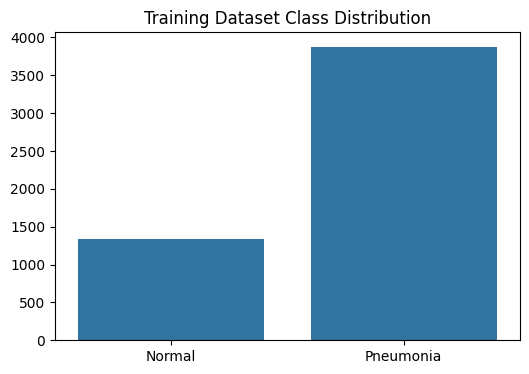

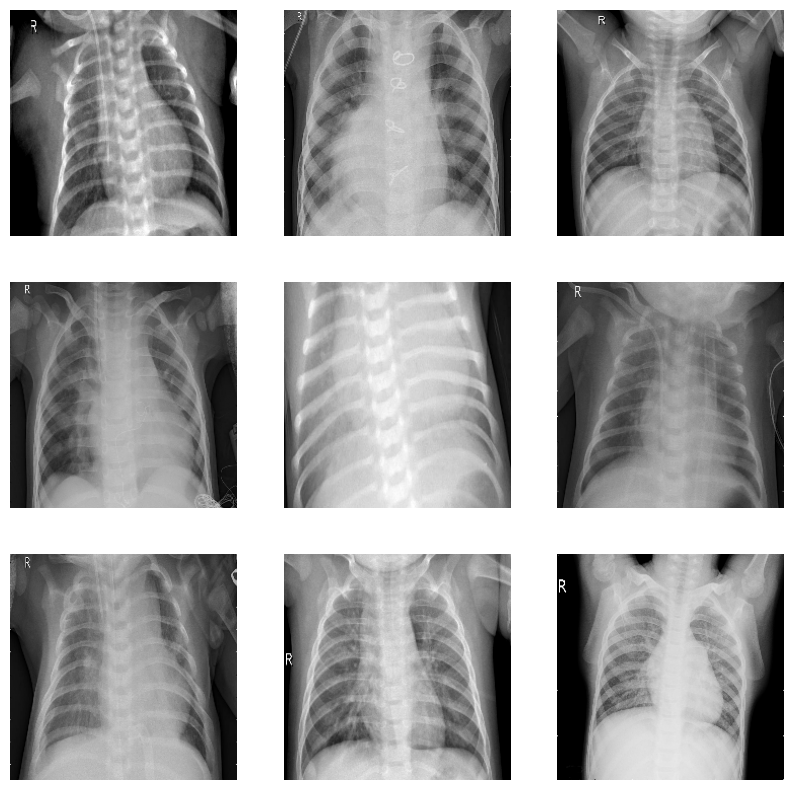

In [6]:
normal_count = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
pneumonia_count = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))

plt.figure(figsize=(6, 4))
sns.barplot(x=['Normal', 'Pneumonia'], y=[normal_count, pneumonia_count])
plt.title('Training Dataset Class Distribution')
plt.show()

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap='gray')
        plt.axis("off")
    break
plt.show()

## 4. Custom CNN Architecture Design
Rather than relying on pre-trained weights immediately, I designed a Sequential Convolutional Neural Network (CNN) from scratch to serve as a powerful baseline feature extractor. 

**High-Level Architecture Breakdown:**
1. **Input & Normalization:** The network ingests `224x224` grayscale matrices. I included a `Rescaling(1./255)` layer to normalize pixel values between 0 and 1, which stabilizes the gradients and significantly speeds up network convergence.
2. **On-the-Fly Augmentation:** To combat the limited size of the pediatric dataset, I integrated data augmentation directly into the model pipeline. Slight rotations and zooms force the model to learn invariant features rather than memorizing the exact pixel locations of the training images.
3. **Hierarchical Feature Extraction (Conv Blocks):** I structured four alternating `Conv2D` and `MaxPooling2D` blocks, progressively increasing the filter depth (32 -> 64 -> 128 -> 128). 
   * The **early layers** detect rudimentary structures like the curvature of the rib cage and diaphragm.
   * The **deeper layers** capture complex, high-level textures such as the cloudy opacities (infiltrates) indicative of pneumonia.
   * **MaxPooling** reduces spatial dimensions, cutting down computational load while ensuring the model remains robust to minor shifts in the X-ray positioning.
4. **Classification Head:** I flattened the 2D feature maps into a 1D vector, passing it through a dense 512-neuron layer. To prevent the model from aggressively overfitting to the training data, I applied an aggressive `Dropout(0.5)` layer (randomly deactivating 50% of the neurons during each epoch). Finally, a single neuron with a `Sigmoid` activation function outputs the binary diagnostic probability.

In [3]:
def create_model():
    model = models.Sequential([
        # Input layer & Rescaling (1 channel for grayscale)
        layers.InputLayer(input_shape=(224, 224, 1)),
        layers.Rescaling(1./255),
        
        # Data Augmentation (Helps generalize the model)
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        # Convolutional Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Convolutional Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Convolutional Block 4
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5), # Prevents overfitting
        layers.Dense(1, activation='sigmoid', dtype='float32') # Output: Normal vs Pneumonia
    ])
    
    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )
    return model

# Create the model inside the GPU strategy scope so it distributes correctly!
with strategy.scope():
    model = create_model()

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,086,337 (49.92 MB)

 Trainable params: 13,086,337 (49.92 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Compilation and Training Strategy
The model is compiled using the `Adam` optimizer with a learning rate of `1e-4` and gradient clipping (`clipnorm=1.0`) to ensure stable updates. To improve training, I used EarlyStopping to prevent overfitting and ReduceLROnPlateau to adjust the learning rate when validation performance stops improving.

In [4]:
# Callbacks to prevent overfitting and adjust learning rate dynamically
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

lr_reduction = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    patience=3, 
    factor=0.3, 
    min_lr=0.000001
)

EPOCHS = 25

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_reduction]
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1777797948.160548    1107 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777797949.132110    1105 cuda_dnn.cc:529] Loaded cuDNN version 91002


82/82 ━━━━━━━━━━━━━━━━━━━━ 23s 168ms/step - accuracy: 0.7439 - loss: 0.5816 - precision: 0.7506 - recall: 0.9846 - val_accuracy: 0.6250 - val_loss: 0.6244 - val_precision: 0.5833 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.8313 - loss: 0.3828 - precision: 0.8408 - recall: 0.9574 - val_accuracy: 0.8750 - val_loss: 0.4579 - val_precision: 0.8750 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.9001 - loss: 0.2458 - precision: 0.9282 - recall: 0.9394 - val_accuracy: 0.8125 - val_loss: 0.4089 - val_precision: 0.8571 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.9184 - loss: 0.2086 - precision: 0.9449 - recall: 0.9463 - val_accuracy: 0.9375 - val_loss: 0.3284 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy

## 6. Visualizing Training Performance
I plotted training and validation accuracy and loss to evaluate how well the model is learning and to check for overfitting.

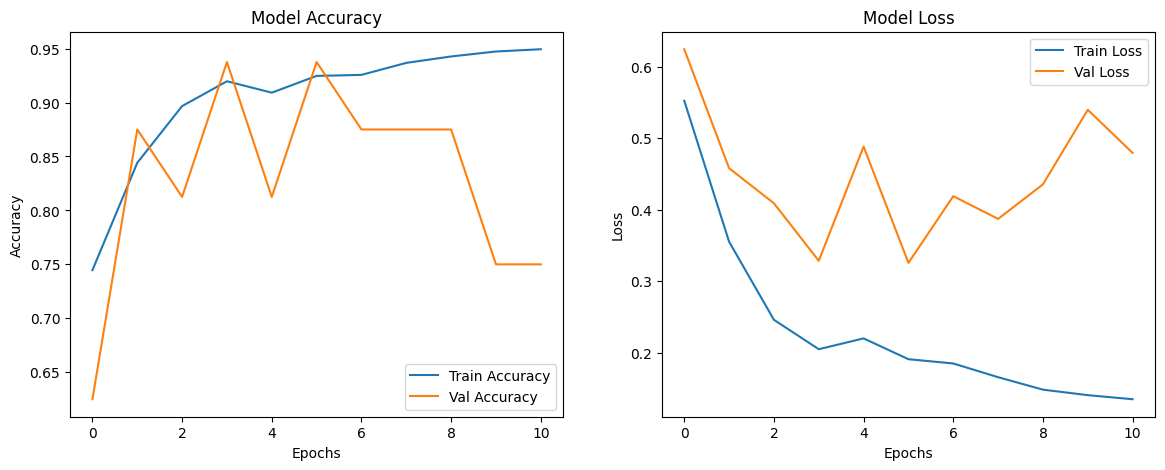

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Plot Loss
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.show()

## 7. Final Evaluation on the Test Set
I evaluated the trained model on the completely unseen `test_dataset` using Keras' built-in `model.evaluate()` function. This returns overall performance metrics including loss, accuracy, precision, and recall, providing a quick summary of how well the model generalizes to new data.

In [6]:
# Evaluate the model on the unseen Test data
print("Evaluating on Test Dataset...")
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_dataset)

print(f"\n--- Final Results on Test Set ---")
print(f"Accuracy:  {test_accuracy * 100:.2f}%")
print(f"Precision: {test_precision * 100:.2f}%")
print(f"Recall:    {test_recall * 100:.2f}%")

Evaluating on Test Dataset...
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.9175 - loss: 0.2373 - precision: 0.6051 - recall: 0.6161 

--- Final Results on Test Set ---
Accuracy:  90.06%
Precision: 94.32%
Recall:    89.49%


## 8. Final Evaluation & Clinical Viability
Once the model was fully trained, I evaluated it against the completely unseen holdout `test_dataset` to measure its real-world generalization.

In medical AI, **Accuracy** alone is not sufficient due to class imbalance. Therefore, I analyzed the Confusion Matrix and classification report to better understand model performance:

* **Precision:** When the model predicts Pneumonia, how often is it correct? (Minimizing False Positives).
* **Recall (Sensitivity):** Out of all actual Pneumonia cases, how many did the model correctly detect? (Minimizing False Negatives).

The Confusion Matrix provides a clear breakdown of predictions, while the classification report summarizes Precision, Recall, and F1-score for each class.

This custom CNN demonstrates that a model trained from scratch can effectively detect lung opacities and provide reliable predictions, making it suitable as a precision-focused diagnostic support tool.

Generating predictions for the Confusion Matrix...


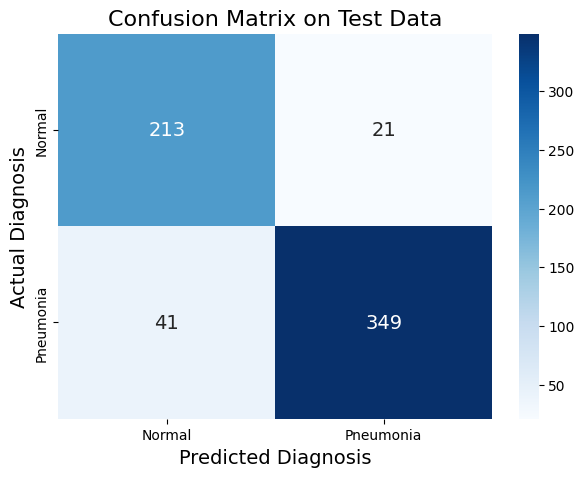


--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.84      0.91      0.87       234
   Pneumonia       0.94      0.89      0.92       390

    accuracy                           0.90       624
   macro avg       0.89      0.90      0.90       624
weighted avg       0.90      0.90      0.90       624



In [7]:
print("Generating predictions for the Confusion Matrix...")

# Get actual labels and model predictions
y_true = []
y_pred_probs = []

# Loop through the test dataset
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

# Convert probabilities to binary predictions (0 for Normal, 1 for Pneumonia)
y_true = np.array(y_true)
y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

# Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix on Test Data', fontsize=16)
plt.ylabel('Actual Diagnosis', fontsize=14)
plt.xlabel('Predicted Diagnosis', fontsize=14)
plt.show()

# Print the detailed classification report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

## 9. Real-World Inference Demo
To demonstrate real-world usage, I implemented a function that loads a chest X-ray image, applies the same preprocessing used during training, and generates a prediction with a confidence score. The result is visualized along with the model’s diagnosis, showing how the trained CNN can be used for practical inference.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step


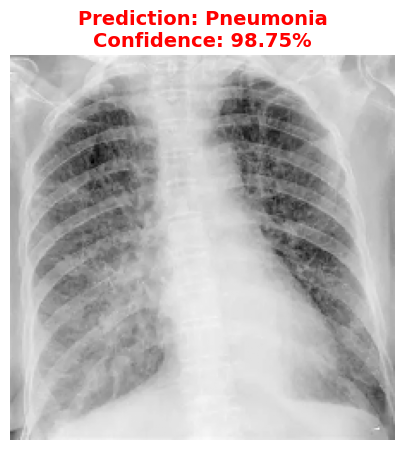

In [32]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_single_image(img_path, trained_model):
    """Load an image, preprocess it, and make a prediction."""
    
    # Load image (224x224 grayscale)
    img = image.load_img(img_path, target_size=(224, 224), color_mode='grayscale')
    
    # Convert to array and expand dimensions
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Predict
    prediction = trained_model.predict(img_batch, verbose=0)
    probability = prediction[0][0]
    
    # Interpret result
    if probability > 0.5:
        diagnosis = "Pneumonia"
        confidence = probability * 100
    else:
        diagnosis = "Normal"
        confidence = (1 - probability) * 100
        
    # Display result
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    plt.title(f"Prediction: {diagnosis}\nConfidence: {confidence:.2f}%", 
              fontsize=14, fontweight='bold', 
              color='red' if diagnosis == "Pneumonia" else 'green')
    plt.axis('off')
    plt.show()

# Run prediction
my_google_image = '/kaggle/input/datasets/tejas5112/pnuemonia/OIP.webp'
predict_single_image(my_google_image, model)

## 10. Model Saving
After training and evaluation, I saved the trained model using Keras' built-in `model.save()` function. This allows the model to be reused later for inference or deployment without retraining.

In [25]:
model.save('pneumonia_detection_model.keras')